In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

# from jax import config
# import scipy.interpolate as interp
import pickle as pk
import numpy as np
# import colossus 
# import configobj

# from base_class import base_class
# from get_radial_profiles import Profiles
# from get_Pkzs import get_Pkz
# from get_Cls import get_Cl
# from get_Xis import get_xi
# from get_covs import get_cov


import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline



/tmp/ipykernel_2757484/3869014615.py:9: DeprecationWarning: jax.lib.xla_bridge module will be removed in JAX v0.9.0; all its APIs were deprecated and removed by JAX v0.8.0.
  from jax.lib import xla_bridge


1 1


In [2]:
# import dill
# probes_all = ["ky_kk_gg_gy_gk_ge", "kk_gg_gk_ge", "kk_gg_gk", "gg_gk_ge", "gg_gk"]
# labels_all = [
#                 r"$C_{gg} + C_{g\kappa} + C_{\kappa \kappa}$" + "\n" + r"$+ C_{gy} + C_{\kappa y} + P_{ge}$",
#                 r"$C_{gg} + C_{g\kappa} + C_{\kappa \kappa}$" + "\n" + r"+ $P_{ge}$",
#                 r"$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$",
#                 r"$C_{gg} + C_{g \kappa}$" + "\n" + r"+ $P_{ge}$",
#                 r"$C_{gg} + C_{g\kappa}$"
# ]
# save_infer_dir = abs_path_results + '/pge/inference/'
# # probes_forecast_all_str = '_'.join(probes_forecast)
# sc_val = 4000
# # num_samples = 4000
# # num_warmup = 3000
# num_samples = 6000
# num_warmup = 6000
# num_chains = 24
# n_parallel = 4
# max_tree_depth = 4


# fig, axes = plt.subplots(2, 3, figsize=(19, 10), sharey=True)
# for jp1 in range(2):
#     for probes_forecast_all_str in probes_all:
        
#         if jp1==1:
#             # savefname_out_dict = save_infer_dir + f'infer_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}_nsel_{nsel}.pkl'
#             savefname_out_dict = save_infer_dir + f'infer_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{True}.pkl'
#         else:
#             savefname_out_dict = save_infer_dir + f'infer_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{True}.pkl'
#             # savefname_out_dict = save_infer_dir + f'infer_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_nsel_{nsel}.pkl'
        
#         out_dict = dill.load(open(savefname_out_dict,'rb'))
#         Pmm_ratio_fid = out_dict['Pmm_ratio_fid'] 
#         Y_model_fid = out_dict['Y_model_fid']
#         fb_model_fid = out_dict['fb_model_fid'] 
        
#         Pmm_ratio_all_samp = out_dict['Pmm_ratio_all_samp'] 
#         Y_M_model_all_samp = out_dict['Y_M_model_all_samp'] 
#         fb_M_model_all_samp = out_dict['fb_M_model_all_samp']
#         Pmm_ratio_all_samp = np.array(Pmm_ratio_all_samp)
#         Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
#         Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        
#         Y_M_model_all_samp = np.array(Y_M_model_all_samp)
#         Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
#         Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)
        
#         fb_M_model_all_samp = np.array(fb_M_model_all_samp)
#         fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
#         fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
                
        
#         k_array = out_dict['k_array']
#         M_array = out_dict['M_array']
#         for jp2 in range(3):
#             ax = axes[jp1, jp2]
#             if jp2 == 0:
#                 ax.fill_between(
#                     k_array,
#                     Pmin/Pmm_ratio_fid, Pmax/Pmm_ratio_fid,
#                     alpha=0.3
#                 )
#                 ax.set_xlim(1e-2, 10)
#                 ax.set_ylabel(r'$\Psi/\Psi_{\rm fid}$')
#                 ax.text(0.12, 0.89, r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$',  fontsize=18, transform=ax.transAxes)        
#                 if jp1 == 1:
#                     ax.set_xlabel(r'$k$ ($h$/Mpc)')
#             if jp2 == 1:
#                 ax.fill_between(
#                     M_array,
#                     Ymin/Y_model_fid, Ymax/Y_model_fid, 
#                     alpha=0.3
#                 )
#                 ax.set_xlim(5e12, 1e15)
#                 ax.text(0.12, 0.89, r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$',  fontsize=18, transform=ax.transAxes)        
#                 if jp1 == 1:
#                     ax.set_xlabel(r'$M$ ($M_{\odot}/h$)')
                
#             if jp2 == 2:
#                 ax.fill_between(
#                     M_array,
#                     fbmin/fb_model_fid, fbmax/fb_model_fid,
#                     alpha=0.3
#                 )      
#                 ax.set_xlim(5e12, 1e15)
#                 ax.text(0.12, 0.89, r'$\Psi=f^{\rm b}_{\rm 200c}(M)$',  fontsize=18, transform=ax.transAxes)        
#                 if jp1 == 1:
#                     ax.set_xlabel(r'$M$ ($M_{\odot}/h$)')

#             ax.axhline(1.0, ls='--', color='k', lw=2.0)
#             ax.set_ylim(0.5, 1.5)
            
#             ax.set_xscale('log')



In [44]:
import dill
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Main Configuration ---

# Directory for inference data
SAVE_INFER_DIR = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'

# File naming parameters
SC_VAL = 2000
NUM_SAMPLES = 6000
NUM_WARMUP = 6000
NUM_CHAINS = 24
N_PARALLEL = 4
MAX_TREE_DEPTH = 4

# Define the different probe configurations with labels and a distinct color for each.
# This makes it easy to add or remove probes.
PROBE_CONFIG = [
    {
        "name": "ky_kk_gg_gy_gk_ge",
        # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa\kappa} + C_{gy} + C_{\kappa y} + P_{ge}$",
        "label": r"Lensing + Galaxies + kSZ + tSZ",
        "color": "#1f77b4",  # Muted Blue,
        "hatch": "///"  
    },
    {
        "name": "kk_gg_gk_ge",
        # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa\kappa} + P_{ge}$",
        "label": r"Lensing + Galaxies + kSZ",
        "color": "#ff7f0e"  # Safety Orange
    },
    {
        "name": "kk_gg_gk",
        # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa\kappa}$",
        "label": r"Lensing + Galaxies",
        "color": "#2ca02c"  # Cooked Asparagus Green
    },
    # {
    #     "name": "gg_gk_ge",
    #     "label": r"$C_{gg} + C_{g\kappa} + P_{ge}$",
    #     "color": "#d62728"  # Brick Red
    # },
    # {
    #     "name": "gg_gk",
    #     "label": r"$C_{gg} + C_{g\kappa}$",
    #     "color": "#9467bd"  # Muted Purple
    # }
]

# --- Plotting Setup ---

# # Create a 2x3 grid of subplots
# fig, axes = plt.subplots(2, 3, figsize=(22, 12), sharey=False)
# plt.style.use('seaborn-v0_8-whitegrid') # Use a clean and professional style

# # --- Data Loading and Plotting Loop ---

# # Loop over the two rows (with and without BAO prior)
# for row_idx, use_bao_prior in enumerate([False, True]):
#     # Loop through each probe configuration
#     for probe_info in PROBE_CONFIG:
#         probes_forecast_str = probe_info["name"]
#         color = probe_info["color"]
        
#         # Construct the filename
#         filename = (
#             f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
#             f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
#             f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}.pkl'
#         )
#         filepath = os.path.join(SAVE_INFER_DIR, filename)

#         # Load the data file, skipping if it doesn't exist
#         try:
#             with open(filepath, 'rb') as f:
#                 out_dict = dill.load(f)
#         except FileNotFoundError:
#             print(f"Warning: File not found, skipping plot. -> {filepath}")
#             continue

#         # --- Data Extraction ---
#         k_array = out_dict['k_array']
#         M_array = out_dict['M_array']
        
#         Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
#         Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
#         Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
#         Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        
#         Y_model_fid = out_dict['Y_model_fid']
#         Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
#         Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
#         Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

#         fb_model_fid = out_dict['fb_model_fid']
#         fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
#         fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
#         fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
#         # --- Prepare plot arguments and panel data ---
#         panel_data = [
#             (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
#             (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
#             (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
#         ]
        
#         fill_kwargs = {'edgecolor': color}
#         if 'hatch' in probe_info:
#             # For hatched regions, don't use a solid fill
#             fill_kwargs['hatch'] = probe_info['hatch']
#             fill_kwargs['facecolor'] = 'none'
#             fill_kwargs['linewidth'] = 1.0 # Make edge more prominent
#         else:
#             # For other regions, use a semi-transparent solid fill
#             fill_kwargs['facecolor'] = color
#             fill_kwargs['alpha'] = 0.4
#             fill_kwargs['linewidth'] = 0.5
            
#         # --- Plot data on all three panels ---
#         for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
#             axes[row_idx, col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)


# # --- Final Styling for All Subplots ---
# panel_details = [
#     {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
#     {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
#     {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
# ]

# for row in range(2):
#     for col in range(3):
#         ax = axes[row, col]
#         details = panel_details[col]
        
#         ax.set_xscale('log')
#         ax.axhline(1.0, ls='--', color='black', lw=1.5, alpha=0.8)
#         ax.set_xlim(details['xlim'])
#         if col == 0:
#             ax.set_ylim(0.9, 1.1)
#         else:
#             ax.set_ylim(0.5, 1.5)
#         ax.tick_params(axis='both', which='major', labelsize=14)
#         ax.text(0.05, 0.9, details['text'], fontsize=18, transform=ax.transAxes, ha='left', va='top')

#         if row == 1: # Only add x-labels to the bottom row
#             ax.set_xlabel(details['xlabel'], fontsize=16)

# # Set shared y-labels and row titles
# axes[0, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=18)
# axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=18)
# axes[0, 1].set_title('Without BAO Prior', fontsize=20, y=1.05)
# axes[1, 1].set_title('With BAO Prior', fontsize=20, y=1.05)


# # --- Create Shared Legend at the Bottom ---
# legend_elements = []
# for info in PROBE_CONFIG:
#     patch_kwargs = {'label': info['label']}
#     if 'hatch' in info:
#         # Create a legend patch that shows the hatch pattern
#         patch_kwargs['hatch'] = info['hatch']
#         patch_kwargs['facecolor'] = 'none'
#         patch_kwargs['edgecolor'] = info['color']
#         patch_kwargs['linewidth'] = 1.0
#     else:
#         # Create a standard solid color patch
#         patch_kwargs['facecolor'] = info['color']
#         patch_kwargs['edgecolor'] = info['color']
#         patch_kwargs['alpha'] = 0.6
    
#     legend_elements.append(Patch(**patch_kwargs))

# fig.legend(
#     handles=legend_elements,
#     loc='lower center',
#     bbox_to_anchor=(0.5, -0.001),
#     frameon=False,
#     fontsize=16,
#     ncol=3 # Arrange legend in 3 columns for a cleaner look
# )

# # Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
# fig.subplots_adjust(bottom=0.2, hspace=0.3)

# # --- Save and Show Plot ---
# sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
# os.makedirs(sdir, exist_ok=True)
# # plt.savefig(os.path.join(sdir, "inference_comparison_hatched.png"), bbox_inches="tight", dpi=150)

# plt.show()


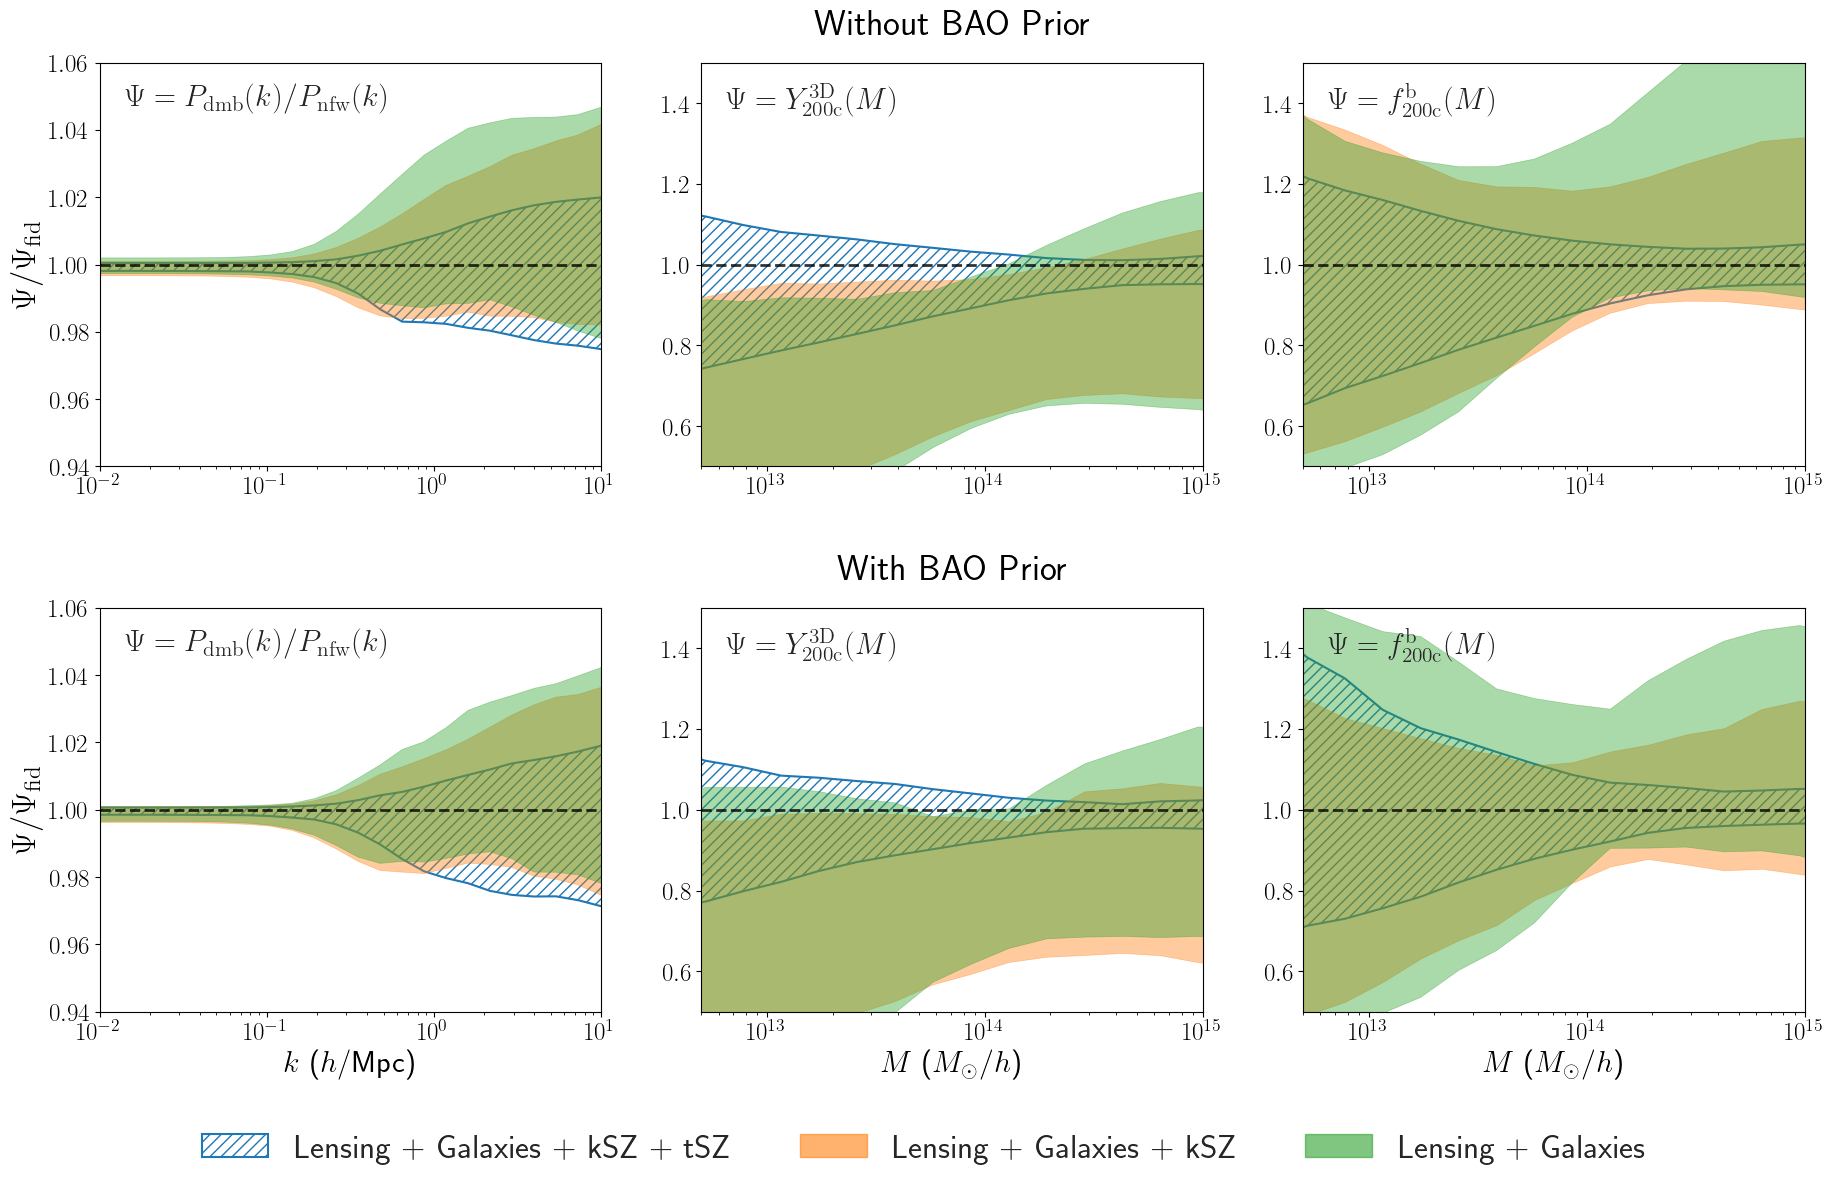

In [4]:
# --- Plotting Setup ---
fig, axes = plt.subplots(2, 3, figsize=(22, 13), sharey=False) # Increased figure height for more space
plt.style.use('seaborn-v0_8-whitegrid')

# --- Data Loading and Plotting Loop ---
for row_idx, use_bao_prior in enumerate([False, True]):
    for probe_info in PROBE_CONFIG:
        probes_forecast_str = probe_info["name"]
        color = probe_info["color"]

        if use_bao_prior:
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}.pkl'
            )
        else:
            if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
                NUM_SAMPLES = 6000
                NUM_WARMUP = 6000
            else:
                NUM_SAMPLES = 4000
                NUM_WARMUP = 3000                
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}.pkl'
            )
            
        filepath = os.path.join(SAVE_INFER_DIR, filename)

        try:
            with open(filepath, 'rb') as f:
                out_dict = dill.load(f)
        except FileNotFoundError:
            print(f"Warning: File not found, skipping plot. -> {filepath}")
            continue

        # --- Data Extraction ---
        k_array = out_dict['k_array']
        M_array = out_dict['M_array']
        
        Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
        Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
        if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
            Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
            Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        else:
            # smooth out the Pmm_ratio_all_samp across k using a rolling average before computing percentiles:
            window_size = 5  # Choose an odd window size for symmetry
            Pmm_ratio_all_samp_smooth = np.array([
                np.convolve(sample/Pmm_ratio_fid, np.ones(window_size)/window_size, mode='same')
                for sample in Pmm_ratio_all_samp
            ])
            Pmin = np.percentile(Pmm_ratio_all_samp_smooth, 16, axis=0) * Pmm_ratio_fid
            Pmax = np.percentile(Pmm_ratio_all_samp_smooth, 84, axis=0) * Pmm_ratio_fid
        
        Y_model_fid = out_dict['Y_model_fid']
        Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
        Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
        Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

        fb_model_fid = out_dict['fb_model_fid']
        fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
        fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
        fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
        panel_data = [
            (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
            (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
            (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
        ]
        
        fill_kwargs = {'edgecolor': color}
        if 'hatch' in probe_info:
            fill_kwargs['hatch'] = probe_info['hatch']
            fill_kwargs['facecolor'] = 'none'
            fill_kwargs['linewidth'] = 1.5 # Make edge more prominent
        else:
            fill_kwargs['facecolor'] = color
            fill_kwargs['alpha'] = 0.4
            fill_kwargs['linewidth'] = 0.5
            
        for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
            axes[row_idx, col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)

# --- Final Styling for All Subplots ---
panel_details = [
    {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
]

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        details = panel_details[col]
        
        ax.set_xscale('log')
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(details['xlim'])

        if col == 0:
            ax.set_ylim(0.94, 1.06)
        else:
            ax.set_ylim(0.5, 1.5)        
        ax.tick_params(axis='both', which='major', labelsize=18) # Increased tick font size
        ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        if row == 1: # Only add x-labels to the bottom row
            ax.set_xlabel(details['xlabel'], fontsize=22) # Increased xlabel font size

# Set shared y-labels and row titles
axes[0, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
axes[0, 1].set_title('Without BAO Prior', fontsize=26, y=1.05) # Increased title font size
axes[1, 1].set_title('With BAO Prior', fontsize=26, y=1.05) # Increased title font size

# --- Create Shared Legend at the Bottom ---
legend_elements = []
for info in PROBE_CONFIG:
    patch_kwargs = {'label': info['label']}
    if 'hatch' in info:
        patch_kwargs['hatch'] = info['hatch']
        patch_kwargs['facecolor'] = 'none'
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['linewidth'] = 1.5
    else:
        patch_kwargs['facecolor'] = info['color']
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['alpha'] = 0.6
    
    legend_elements.append(Patch(**patch_kwargs))

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01), # Moved legend closer to the plot
    frameon=False,
    fontsize=24, # Increased legend font size
    ncol=3
)

# Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.35) # Adjusted bottom margin and vertical space

# --- Save and Show Plot ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
# plt.savefig(os.path.join(sdir, "inference_comparison.pdf"), bbox_inches="tight", dpi=200)

plt.show()




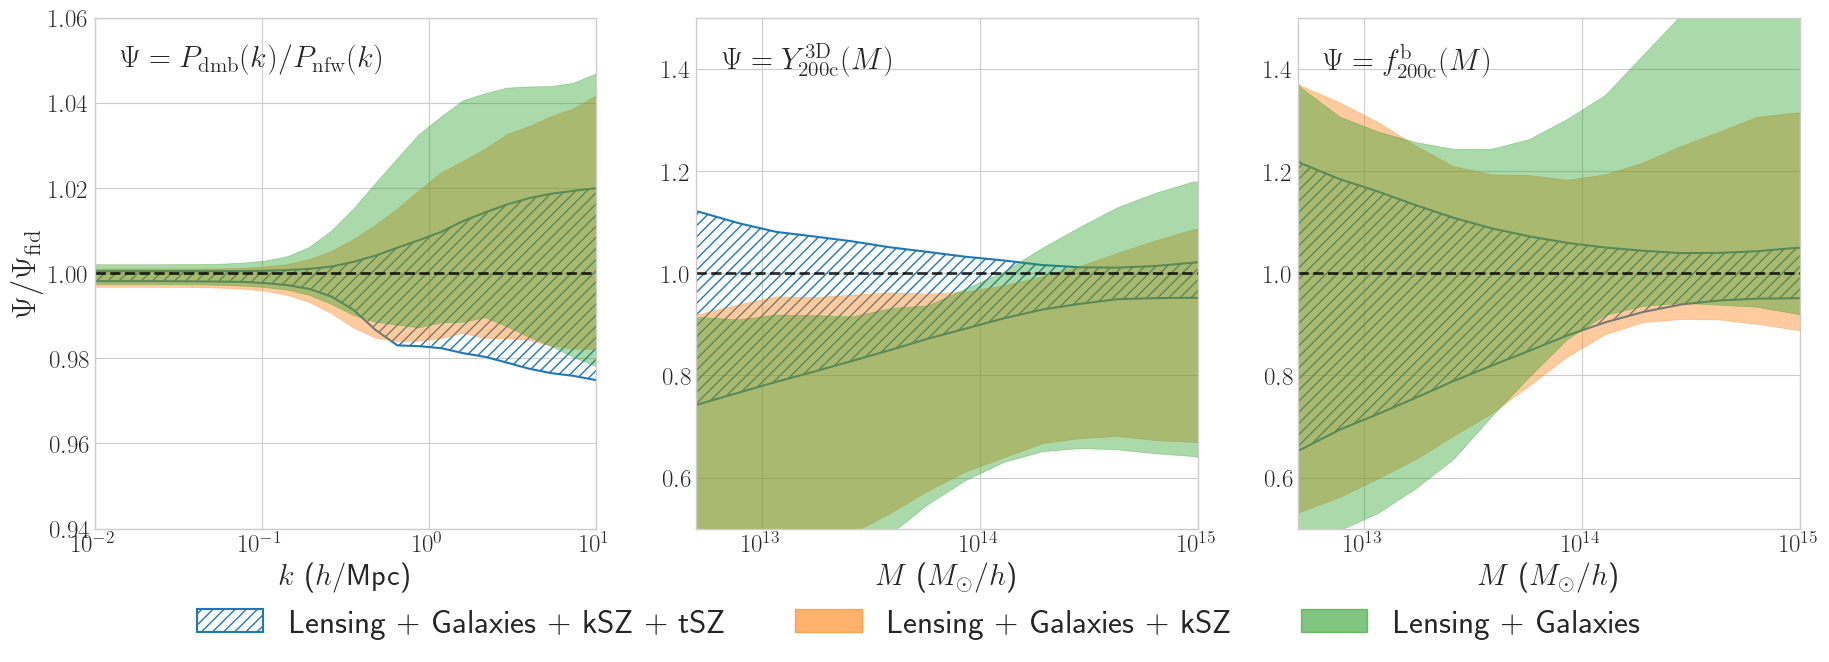

In [5]:
# --- Plotting Setup ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False) # Increased figure height for more space
plt.style.use('seaborn-v0_8-whitegrid')

# --- Data Loading and Plotting Loop ---
for row_idx, use_bao_prior in enumerate([False]):
    for probe_info in PROBE_CONFIG:
        probes_forecast_str = probe_info["name"]
        color = probe_info["color"]

        if use_bao_prior:
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}.pkl'
            )
        else:
            if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
                NUM_SAMPLES = 6000
                NUM_WARMUP = 6000
            else:
                NUM_SAMPLES = 4000
                NUM_WARMUP = 3000                
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}.pkl'
            )
            
        filepath = os.path.join(SAVE_INFER_DIR, filename)

        try:
            with open(filepath, 'rb') as f:
                out_dict = dill.load(f)
        except FileNotFoundError:
            print(f"Warning: File not found, skipping plot. -> {filepath}")
            continue

        # --- Data Extraction ---
        k_array = out_dict['k_array']
        M_array = out_dict['M_array']
        
        Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
        Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
        if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
            Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
            Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        else:
            # smooth out the Pmm_ratio_all_samp across k using a rolling average before computing percentiles:
            window_size = 5  # Choose an odd window size for symmetry
            Pmm_ratio_all_samp_smooth = np.array([
                np.convolve(sample/Pmm_ratio_fid, np.ones(window_size)/window_size, mode='same')
                for sample in Pmm_ratio_all_samp
            ])
            Pmin = np.percentile(Pmm_ratio_all_samp_smooth, 16, axis=0) * Pmm_ratio_fid
            Pmax = np.percentile(Pmm_ratio_all_samp_smooth, 84, axis=0) * Pmm_ratio_fid
        
        Y_model_fid = out_dict['Y_model_fid']
        Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
        Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
        Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

        fb_model_fid = out_dict['fb_model_fid']
        fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
        fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
        fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
        panel_data = [
            (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
            (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
            (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
        ]
        
        fill_kwargs = {'edgecolor': color}
        if 'hatch' in probe_info:
            fill_kwargs['hatch'] = probe_info['hatch']
            fill_kwargs['facecolor'] = 'none'
            fill_kwargs['linewidth'] = 1.5 # Make edge more prominent
        else:
            fill_kwargs['facecolor'] = color
            fill_kwargs['alpha'] = 0.4
            fill_kwargs['linewidth'] = 0.5
            
        for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
            axes[col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)

# --- Final Styling for All Subplots ---
panel_details = [
    {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
]

for row in range(1):
    for col in range(3):
        ax = axes[col]
        details = panel_details[col]
        
        ax.set_xscale('log')
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(details['xlim'])

        if col == 0:
            ax.set_ylim(0.94, 1.06)
        else:
            ax.set_ylim(0.5, 1.5)        
        ax.tick_params(axis='both', which='major', labelsize=18) # Increased tick font size
        ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        if row == 0: # Only add x-labels to the bottom row
            ax.set_xlabel(details['xlabel'], fontsize=22) # Increased xlabel font size

# Set shared y-labels and row titles
axes[0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[0, 1].set_title('Without BAO Prior', fontsize=26, y=1.05) # Increased title font size
# axes[1, 1].set_title('With BAO Prior', fontsize=26, y=1.05) # Increased title font size

# --- Create Shared Legend at the Bottom ---
legend_elements = []
for info in PROBE_CONFIG:
    patch_kwargs = {'label': info['label']}
    if 'hatch' in info:
        patch_kwargs['hatch'] = info['hatch']
        patch_kwargs['facecolor'] = 'none'
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['linewidth'] = 1.5
    else:
        patch_kwargs['facecolor'] = info['color']
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['alpha'] = 0.6
    
    legend_elements.append(Patch(**patch_kwargs))

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Moved legend closer to the plot
    frameon=False,
    fontsize=24, # Increased legend font size
    ncol=3
)

# Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.35) # Adjusted bottom margin and vertical space

# --- Save and Show Plot ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
# plt.savefig(os.path.join(sdir, "inference_comparison_wobao.pdf"), bbox_inches="tight", dpi=200)

plt.show()




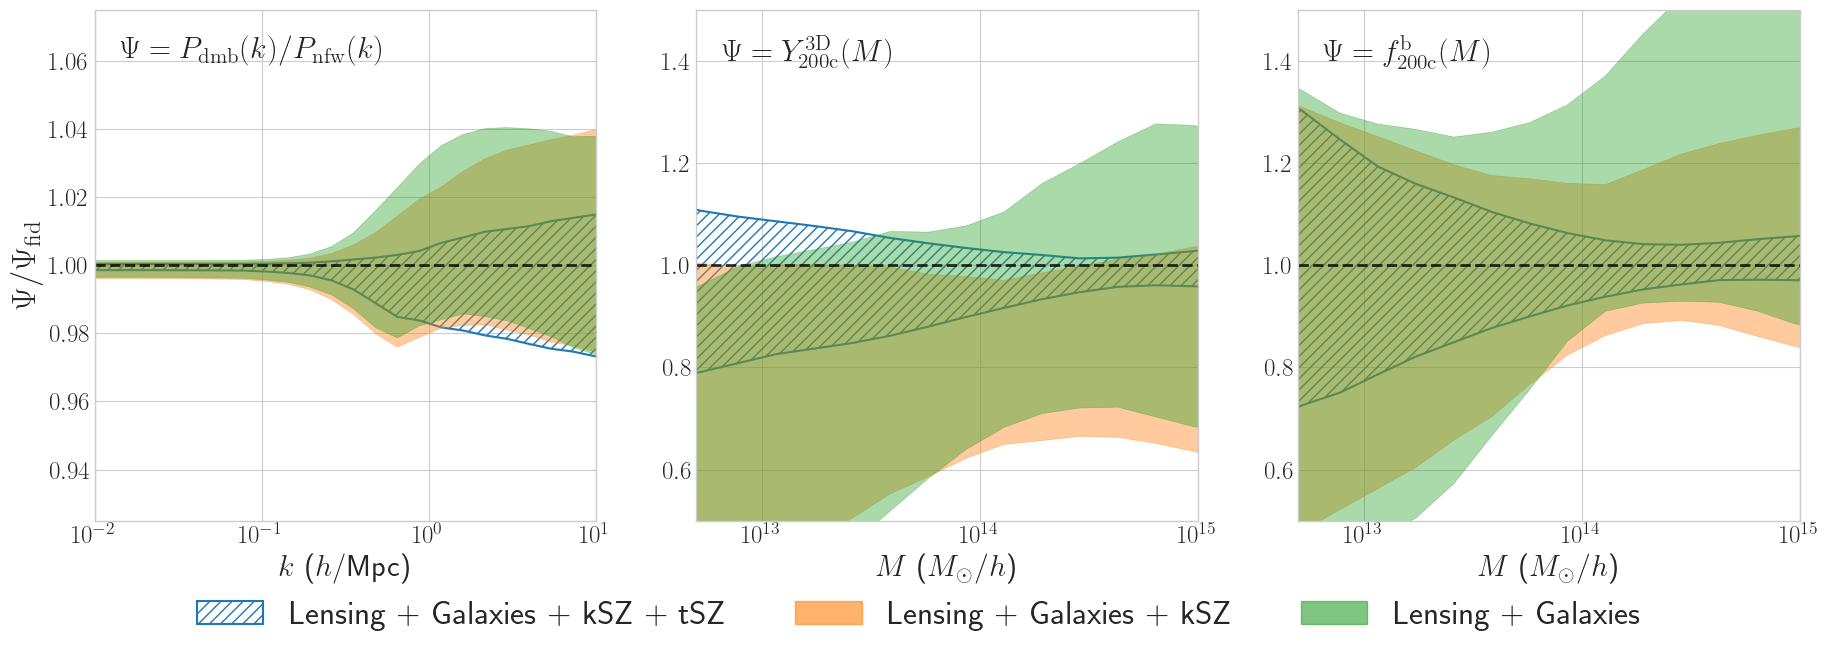

In [5]:
# --- Plotting Setup ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False) # Increased figure height for more space
plt.style.use('seaborn-v0_8-whitegrid')

# --- Data Loading and Plotting Loop ---
for row_idx, use_bao_prior in enumerate([False]):
    for probe_info in PROBE_CONFIG:
        probes_forecast_str = probe_info["name"]
        color = probe_info["color"]

        if use_bao_prior:
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024.pkl'
            )
        else:
            # if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            # else:
            #     NUM_SAMPLES = 4000
            #     NUM_WARMUP = 3000                
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024.pkl'
            )
            
        filepath = os.path.join(SAVE_INFER_DIR, filename)

        try:
            with open(filepath, 'rb') as f:
                out_dict = dill.load(f)
        except FileNotFoundError:
            print(f"Warning: File not found, skipping plot. -> {filepath}")
            continue

        # --- Data Extraction ---
        k_array = out_dict['k_array']
        M_array = out_dict['M_array']
        
        Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
        Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
        Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
        Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        
        Y_model_fid = out_dict['Y_model_fid']
        Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
        Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
        Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

        fb_model_fid = out_dict['fb_model_fid']
        fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
        fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
        fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
        panel_data = [
            (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
            (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
            (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
        ]
        
        fill_kwargs = {'edgecolor': color}
        if 'hatch' in probe_info:
            fill_kwargs['hatch'] = probe_info['hatch']
            fill_kwargs['facecolor'] = 'none'
            fill_kwargs['linewidth'] = 1.5 # Make edge more prominent
        else:
            fill_kwargs['facecolor'] = color
            fill_kwargs['alpha'] = 0.4
            fill_kwargs['linewidth'] = 0.5
            
        for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
            axes[col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)

# --- Final Styling for All Subplots ---
panel_details = [
    {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
]

for row in range(1):
    for col in range(3):
        ax = axes[col]
        details = panel_details[col]
        
        ax.set_xscale('log')
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(details['xlim'])

        if col == 0:
            ax.set_ylim(0.925, 1.075)
        else:
            ax.set_ylim(0.5, 1.5)        
        ax.tick_params(axis='both', which='major', labelsize=18) # Increased tick font size
        ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        if row == 0: # Only add x-labels to the bottom row
            ax.set_xlabel(details['xlabel'], fontsize=22) # Increased xlabel font size

# Set shared y-labels and row titles
axes[0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[0, 1].set_title('Without BAO Prior', fontsize=26, y=1.05) # Increased title font size
# axes[1, 1].set_title('With BAO Prior', fontsize=26, y=1.05) # Increased title font size

# --- Create Shared Legend at the Bottom ---
legend_elements = []
for info in PROBE_CONFIG:
    patch_kwargs = {'label': info['label']}
    if 'hatch' in info:
        patch_kwargs['hatch'] = info['hatch']
        patch_kwargs['facecolor'] = 'none'
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['linewidth'] = 1.5
    else:
        patch_kwargs['facecolor'] = info['color']
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['alpha'] = 0.6
    
    legend_elements.append(Patch(**patch_kwargs))

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Moved legend closer to the plot
    frameon=False,
    fontsize=24, # Increased legend font size
    ncol=3
)

# Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.35) # Adjusted bottom margin and vertical space

# --- Save and Show Plot ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
# plt.savefig(os.path.join(sdir, "inference_comparison_wobao.pdf"), bbox_inches="tight", dpi=200)

plt.show()




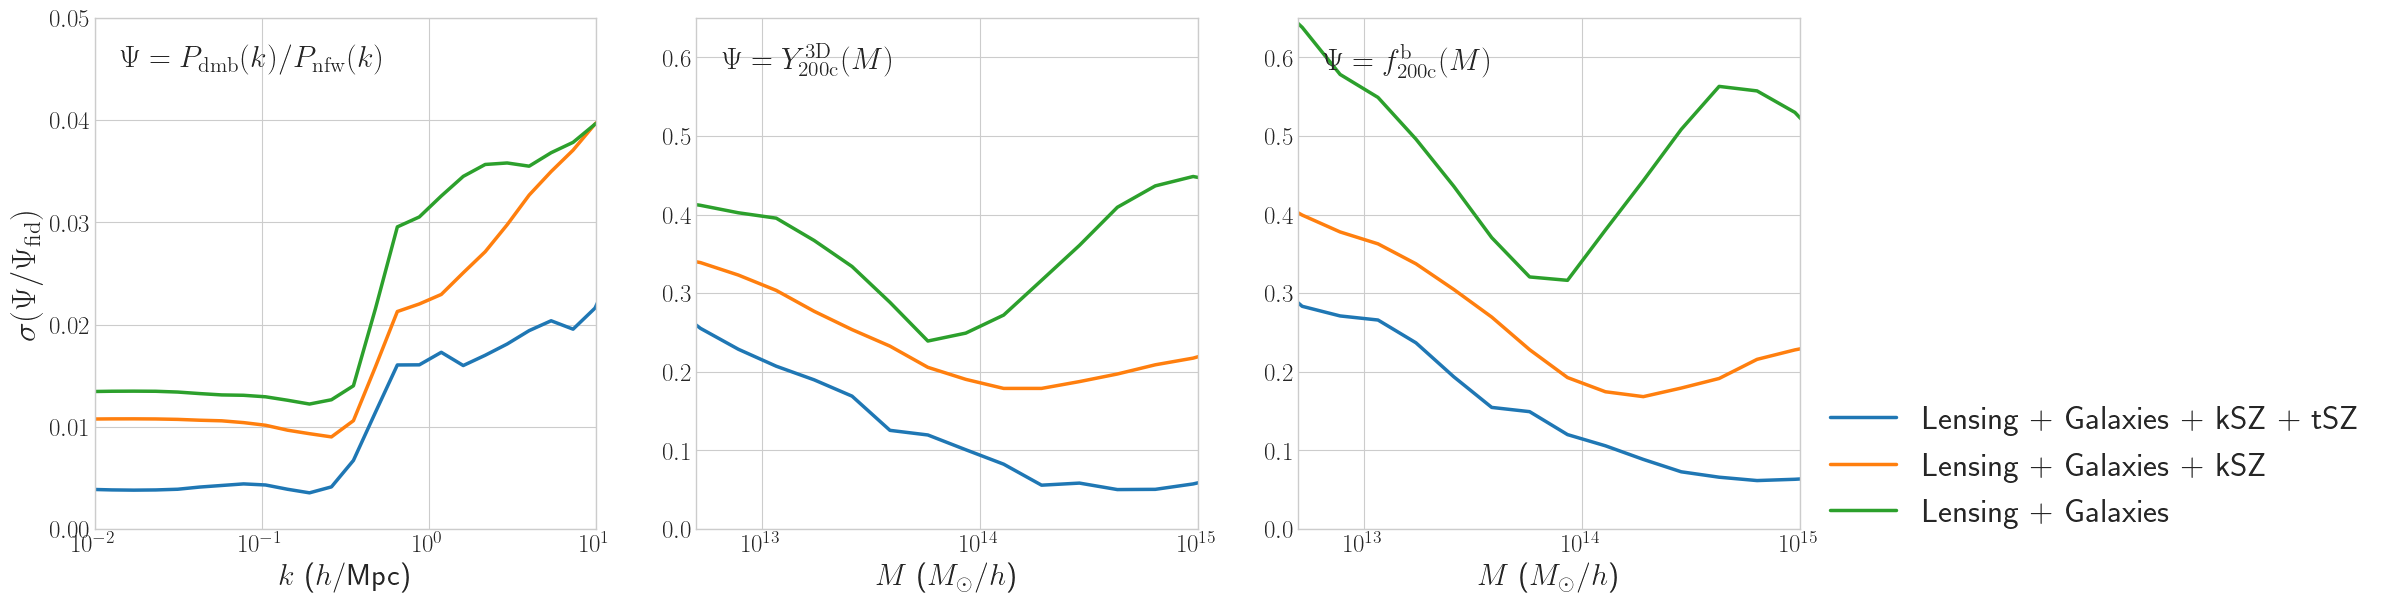

In [49]:
# --- Plotting Setup ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False) # Increased figure height for more space
plt.style.use('seaborn-v0_8-whitegrid')

# --- Data Loading and Plotting Loop ---
for row_idx, use_bao_prior in enumerate([False]):
    for probe_info in PROBE_CONFIG:
        probes_forecast_str = probe_info["name"]
        color = probe_info["color"]

        if use_bao_prior:
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024_v2.pkl'
            )
        else:
            # if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            # else:
            #     NUM_SAMPLES = 4000
            #     NUM_WARMUP = 3000                
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024_v2.pkl'
            )
            
        filepath = os.path.join(SAVE_INFER_DIR, filename)

        try:
            with open(filepath, 'rb') as f:
                out_dict = dill.load(f)
        except FileNotFoundError:
            print(f"Warning: File not found, skipping plot. -> {filepath}")
            continue

        # --- Data Extraction ---
        k_array = out_dict['k_array']
        M_array = out_dict['M_array']
        
        Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
        Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
        Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
        Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        
        Y_model_fid = out_dict['Y_model_fid']
        Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
        Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
        Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

        fb_model_fid = out_dict['fb_model_fid']
        fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
        fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
        fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
        panel_data = [
            (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
            (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
            (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
        ]
        
        # fill_kwargs = {'edgecolor': color}
        # if 'hatch' in probe_info:
        #     # fill_kwargs['hatch'] = probe_info['hatch']
        #     fill_kwargs['facecolor'] = 'none'
        #     fill_kwargs['linewidth'] = 1.5 # Make edge more prominent
        # else:
            # fill_kwargs['facecolor'] = color
            # fill_kwargs['alpha'] = 0.4
            # fill_kwargs['linewidth'] = 0.5
        fill_kwargs = {'ls': '-', 'lw': 2.5, 'color': color, 'label': probe_info['label']}
        for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
            # axes[col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)
            axes[col_idx].plot(x_data, 0.5*(y_max - y_min), **fill_kwargs)

# --- Final Styling for All Subplots ---
panel_details = [
    {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
]

for row in range(1):
    for col in range(3):
        ax = axes[col]
        details = panel_details[col]
        
        ax.set_xscale('log')
        # ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(details['xlim'])

        if col == 0:
            # ax.set_ylim(0.925, 1.075)
            ax.set_ylim(0, 0.05)      
        else:
            # ax.set_ylim(0.5, 1.5)        
            ax.set_ylim(0., 0.65)     
        if col == 2:
            ax.legend(frameon=False,
                        fontsize=24, # Increased legend font size
                        ncol=1
                        , bbox_to_anchor=(1.0, 0.3))            

        ax.tick_params(axis='both', which='major', labelsize=18) # Increased tick font size
        ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        if row == 0: # Only add x-labels to the bottom row
            ax.set_xlabel(details['xlabel'], fontsize=22) # Increased xlabel font size

# Set shared y-labels and row titles
axes[0].set_ylabel(r'$\sigma(\Psi/\Psi_{\rm fid})$', fontsize=24) # Increased ylabel font size
# axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[0, 1].set_title('Without BAO Prior', fontsize=26, y=1.05) # Increased title font size
# axes[1, 1].set_title('With BAO Prior', fontsize=26, y=1.05) # Increased title font size

# --- Create Shared Legend at the Bottom ---
# legend_elements = []
# for info in PROBE_CONFIG:
#     patch_kwargs = {'label': info['label']}
#     # if 'hatch' in info:
#     #     patch_kwargs['hatch'] = info['hatch']
#     #     patch_kwargs['facecolor'] = 'none'
#     #     patch_kwargs['edgecolor'] = info['color']
#     #     patch_kwargs['linewidth'] = 1.5
#     # else:
#     #     patch_kwargs['facecolor'] = info['color']
#     #     patch_kwargs['edgecolor'] = info['color']
#     #     patch_kwargs['alpha'] = 0.6
#     patch_kwargs['color'] = info['color']
#     patch_kwargs['ls'] = '-'

#     legend_elements.append(Line(**patch_kwargs))

# fig.legend(
#     handles=legend_elements,
#     loc='lower center',
#     bbox_to_anchor=(0.5, -0.05), # Moved legend closer to the plot
#     frameon=False,
#     fontsize=24, # Increased legend font size
#     ncol=3
# )

# Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.35) # Adjusted bottom margin and vertical space

# --- Save and Show Plot ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
# plt.savefig(os.path.join(sdir, "inference_comparison_wobao.pdf"), bbox_inches="tight", dpi=200)
plt.savefig(os.path.join(sdir, "inference_comparison_astro.pdf"), bbox_inches="tight", dpi=200)
plt.show()




In [ ]:
# Pmm_ratio_fid.shape



(48,)

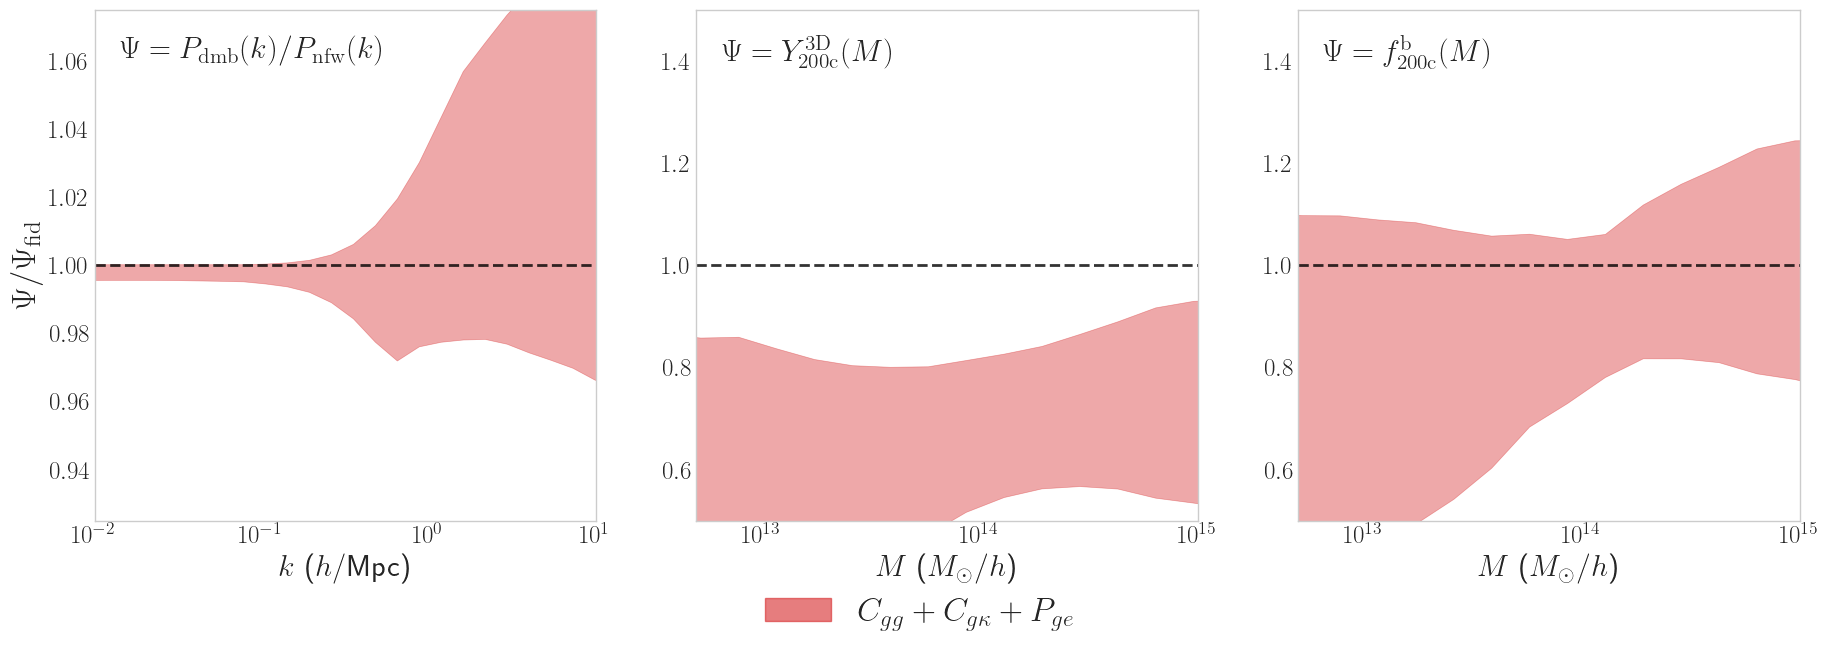

In [6]:
import dill
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# --- Main Configuration ---

# Directory for inference data
SAVE_INFER_DIR = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'

# File naming parameters
SC_VAL = 4000
NUM_SAMPLES = 6000
NUM_WARMUP = 6000
NUM_CHAINS = 24
N_PARALLEL = 4
MAX_TREE_DEPTH = 4

# Define the different probe configurations with labels and a distinct color for each.
# This makes it easy to add or remove probes.
PROBE_CONFIG = [
    # {
    #     "name": "ky_kk_gg_gy_gk_ge",
    #     # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa\kappa} + C_{gy} + C_{\kappa y} + P_{ge}$",
    #     "label": r"Lensing + Galaxies + kSZ + tSZ",
    #     "color": "#1f77b4",  # Muted Blue,
    #     "hatch": "///"  
    # },
    # {
    #     "name": "kk_gg_gk_ge",
    #     # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa\kappa} + P_{ge}$",
    #     "label": r"Lensing + Galaxies + kSZ",
    #     "color": "#ff7f0e"  # Safety Orange
    # },
    # {
    #     "name": "kk_gg_gk",
    #     # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa\kappa}$",
    #     "label": r"Lensing + Galaxies",
    #     "color": "#2ca02c"  # Cooked Asparagus Green
    # },
    {
        "name": "gg_gk_ge",
        "label": r"$C_{gg} + C_{g\kappa} + P_{ge}$",
        "color": "#d62728"  # Brick Red
    },
    # {
    #     "name": "gg_gk",
    #     "label": r"$C_{gg} + C_{g\kappa}$",
    #     "color": "#9467bd"  # Muted Purple
    # }
]

# --- Plotting Setup ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False) # Increased figure height for more space
plt.style.use('seaborn-v0_8-whitegrid')

# --- Data Loading and Plotting Loop ---
for row_idx, use_bao_prior in enumerate([False]):
    for probe_info in PROBE_CONFIG:
        probes_forecast_str = probe_info["name"]
        color = probe_info["color"]

        if use_bao_prior:
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024.pkl'
            )
        else:
            # if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            # else:
            #     NUM_SAMPLES = 4000
            #     NUM_WARMUP = 3000                
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024.pkl'
            )
            
        filepath = os.path.join(SAVE_INFER_DIR, filename)

        try:
            with open(filepath, 'rb') as f:
                out_dict = dill.load(f)
        except FileNotFoundError:
            print(f"Warning: File not found, skipping plot. -> {filepath}")
            continue

        # --- Data Extraction ---
        k_array = out_dict['k_array']
        M_array = out_dict['M_array']
        
        Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
        Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
        Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
        Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        
        Y_model_fid = out_dict['Y_model_fid']
        Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
        Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
        Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

        fb_model_fid = out_dict['fb_model_fid']
        fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
        fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
        fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
        panel_data = [
            (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
            (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
            (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
        ]
        
        fill_kwargs = {'edgecolor': color}
        if 'hatch' in probe_info:
            fill_kwargs['hatch'] = probe_info['hatch']
            fill_kwargs['facecolor'] = 'none'
            fill_kwargs['linewidth'] = 1.5 # Make edge more prominent
        else:
            fill_kwargs['facecolor'] = color
            fill_kwargs['alpha'] = 0.4
            fill_kwargs['linewidth'] = 0.5
            
        for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
            axes[col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)
            axes[col_idx].grid()
# --- Final Styling for All Subplots ---
panel_details = [
    {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
]

for row in range(1):
    for col in range(3):
        ax = axes[col]
        details = panel_details[col]
        
        ax.set_xscale('log')
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(details['xlim'])

        if col == 0:
            ax.set_ylim(0.925, 1.075)
        else:
            ax.set_ylim(0.5, 1.5)        
        ax.tick_params(axis='both', which='major', labelsize=18) # Increased tick font size
        ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        if row == 0: # Only add x-labels to the bottom row
            ax.set_xlabel(details['xlabel'], fontsize=22) # Increased xlabel font size

# Set shared y-labels and row titles
axes[0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[0, 1].set_title('Without BAO Prior', fontsize=26, y=1.05) # Increased title font size
# axes[1, 1].set_title('With BAO Prior', fontsize=26, y=1.05) # Increased title font size

# --- Create Shared Legend at the Bottom ---
legend_elements = []
for info in PROBE_CONFIG:
    patch_kwargs = {'label': info['label']}
    if 'hatch' in info:
        patch_kwargs['hatch'] = info['hatch']
        patch_kwargs['facecolor'] = 'none'
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['linewidth'] = 1.5
    else:
        patch_kwargs['facecolor'] = info['color']
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['alpha'] = 0.6
    
    legend_elements.append(Patch(**patch_kwargs))

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Moved legend closer to the plot
    frameon=False,
    fontsize=24, # Increased legend font size
    ncol=3
)

# Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.35) # Adjusted bottom margin and vertical space

# --- Save and Show Plot ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
# plt.savefig(os.path.join(sdir, "inference_comparison_wobao.pdf"), bbox_inches="tight", dpi=200)

plt.show()




In [ ]:
# --- Plotting Setup ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=False) # Increased figure height for more space
plt.style.use('seaborn-v0_8-whitegrid')

# --- Data Loading and Plotting Loop ---
for row_idx, use_bao_prior in enumerate([False]):
    for probe_info in PROBE_CONFIG:
        probes_forecast_str = probe_info["name"]
        color = probe_info["color"]

        if use_bao_prior:
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024.pkl'
            )
        else:
            # if probes_forecast_str == 'ky_kk_gg_gy_gk_ge':
            NUM_SAMPLES = 6000
            NUM_WARMUP = 6000
            # else:
            #     NUM_SAMPLES = 4000
            #     NUM_WARMUP = 3000                
            filename = (
                f'infer_v5_{probes_forecast_str}_scval_{SC_VAL}_samples_{NUM_SAMPLES}_'
                f'warmup_{NUM_WARMUP}_num_chains_{NUM_CHAINS * N_PARALLEL}_'
                f'treedepth_{MAX_TREE_DEPTH}_wbaoprior_{use_bao_prior}_nsel_1024.pkl'
            )
            
        filepath = os.path.join(SAVE_INFER_DIR, filename)

        try:
            with open(filepath, 'rb') as f:
                out_dict = dill.load(f)
        except FileNotFoundError:
            print(f"Warning: File not found, skipping plot. -> {filepath}")
            continue

        # --- Data Extraction ---
        k_array = out_dict['k_array']
        M_array = out_dict['M_array']
        
        Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
        Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])
        Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
        Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)
        
        Y_model_fid = out_dict['Y_model_fid']
        Y_M_model_all_samp = np.array(out_dict['Y_M_model_all_samp'])
        Ymin = np.percentile(Y_M_model_all_samp, 16, axis=0)
        Ymax = np.percentile(Y_M_model_all_samp, 84, axis=0)

        fb_model_fid = out_dict['fb_model_fid']
        fb_M_model_all_samp = np.array(out_dict['fb_M_model_all_samp'])
        fbmin = np.percentile(fb_M_model_all_samp, 16, axis=0)
        fbmax = np.percentile(fb_M_model_all_samp, 84, axis=0)
        
        panel_data = [
            (k_array, Pmin / Pmm_ratio_fid, Pmax / Pmm_ratio_fid),
            (M_array, Ymin / Y_model_fid, Ymax / Y_model_fid),
            (M_array, fbmin / fb_model_fid, fbmax / fb_model_fid)
        ]
        
        fill_kwargs = {'edgecolor': color}
        if 'hatch' in probe_info:
            fill_kwargs['hatch'] = probe_info['hatch']
            fill_kwargs['facecolor'] = 'none'
            fill_kwargs['linewidth'] = 1.5 # Make edge more prominent
        else:
            fill_kwargs['facecolor'] = color
            fill_kwargs['alpha'] = 0.4
            fill_kwargs['linewidth'] = 0.5
            
        for col_idx, (x_data, y_min, y_max) in enumerate(panel_data):
            axes[col_idx].fill_between(x_data, y_min, y_max, **fill_kwargs)

# --- Final Styling for All Subplots ---
panel_details = [
    {'xlabel': r'$k$ ($h$/Mpc)', 'xlim': (1e-2, 10), 'text': r'$\Psi=P_{\rm dmb}(k)/P_{\rm nfw}(k)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=Y^{\rm 3D}_{\rm 200c}(M)$'},
    {'xlabel': r'$M$ ($M_{\odot}/h$)', 'xlim': (5e12, 1e15), 'text': r'$\Psi=f^{\rm b}_{\rm 200c}(M)$'}
]

for row in range(1):
    for col in range(3):
        ax = axes[col]
        details = panel_details[col]
        
        ax.set_xscale('log')
        ax.axhline(1.0, ls='--', color='black', lw=2.0, alpha=0.8)
        ax.set_xlim(details['xlim'])

        if col == 0:
            ax.set_ylim(0.925, 1.075)
        else:
            ax.set_ylim(0.5, 1.5)        
        ax.tick_params(axis='both', which='major', labelsize=18) # Increased tick font size
        ax.text(0.05, 0.95, details['text'], fontsize=22, transform=ax.transAxes, ha='left', va='top') # Increased text font size

        if row == 0: # Only add x-labels to the bottom row
            ax.set_xlabel(details['xlabel'], fontsize=22) # Increased xlabel font size

# Set shared y-labels and row titles
axes[0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[1, 0].set_ylabel(r'$\Psi/\Psi_{\rm fid}$', fontsize=24) # Increased ylabel font size
# axes[0, 1].set_title('Without BAO Prior', fontsize=26, y=1.05) # Increased title font size
# axes[1, 1].set_title('With BAO Prior', fontsize=26, y=1.05) # Increased title font size

# --- Create Shared Legend at the Bottom ---
legend_elements = []
for info in PROBE_CONFIG:
    patch_kwargs = {'label': info['label']}
    if 'hatch' in info:
        patch_kwargs['hatch'] = info['hatch']
        patch_kwargs['facecolor'] = 'none'
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['linewidth'] = 1.5
    else:
        patch_kwargs['facecolor'] = info['color']
        patch_kwargs['edgecolor'] = info['color']
        patch_kwargs['alpha'] = 0.6
    
    legend_elements.append(Patch(**patch_kwargs))

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05), # Moved legend closer to the plot
    frameon=False,
    fontsize=24, # Increased legend font size
    ncol=3
)

# Adjust layout to prevent overlap and make room for the legend
# plt.tight_layout()
fig.subplots_adjust(bottom=0.15, hspace=0.35) # Adjusted bottom margin and vertical space

# --- Save and Show Plot ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
# plt.savefig(os.path.join(sdir, "inference_comparison_wobao.pdf"), bbox_inches="tight", dpi=200)

plt.show()




(0.6, 1.05)

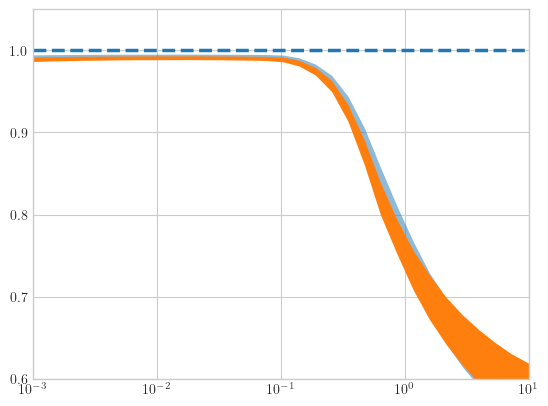

In [26]:
SAVE_INFER_DIR = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'
filepath = SAVE_INFER_DIR + 'infer_v5_gg_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
with open(filepath, 'rb') as f:
    out_dict = dill.load(f)

k_array = out_dict['k_array']
M_array = out_dict['M_array']

Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])

Pmin_wpge = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
Pmax_wpge = np.percentile(Pmm_ratio_all_samp, 84, axis=0)


SAVE_INFER_DIR = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/inference/'
filepath = SAVE_INFER_DIR + 'infer_v5_gg_gk_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_False_nsel_1024.pkl'
with open(filepath, 'rb') as f:
    out_dict = dill.load(f)

k_array = out_dict['k_array']
M_array = out_dict['M_array']

Pmm_ratio_fid = out_dict['Pmm_ratio_fid']
Pmm_ratio_all_samp = np.array(out_dict['Pmm_ratio_all_samp'])

Pmin = np.percentile(Pmm_ratio_all_samp, 16, axis=0)
Pmax = np.percentile(Pmm_ratio_all_samp, 84, axis=0)


pl.figure()
# for js in range(Pmm_ratio_all_samp.shape[0]):
    # pl.plot(k_array, Pmm_ratio_all_samp[js,:], alpha=0.05)
# pl.fill_between(k_array, Pmin/Pmm_ratio_fid, Pmax/Pmm_ratio_fid, alpha=0.5)
# pl.fill_between(k_array, Pmin_wpge/Pmm_ratio_fid, Pmax_wpge/Pmm_ratio_fid, alpha=0.5)
pl.fill_between(k_array, Pmin, Pmax, alpha=0.5)
pl.fill_between(k_array, Pmin_wpge, Pmax_wpge, alpha=1.0)
pl.axhline(1.0, ls='--', lw=2.5)
pl.xscale('log')
pl.xlim(0.001, 10)
pl.ylim(0.6, 1.05)
# pl.ylim(0.8,1.4)




In [13]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
import yaml
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

        

import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
from numpyro.infer.reparam import LocScaleReparam, TransformReparam
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj
import copy
import yaml
from deepmerge import always_merger
import ast 

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov

import jax_cosmo.background as bkgrd
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
import yaml
from deepmerge import always_merger
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
import jax_cosmo.background as bkgrd
import getdist
from getdist import plots, MCSamples
from tqdm import tqdm
import ast
import argparse
from scipy.interpolate import interp1d
import astropy.units as u
from astropy import constants as const
import warnings
warnings.filterwarnings("ignore")

def get_samps(fname, param_acorr='sigma8', true_val=0.8, ess_thresh = 100, acorr_min=0.035, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.0, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
    
    # acorr = autocorrelation(sig8_rs, axis=1)
    # ind_del = []
    # for ji in range(acorr.shape[0]):
    #     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
    #         ind_del.append(ji)    

    ess_per_chain = effective_sample_size(jnp.asarray(sig8_rs))
    
    ind_del = []
    for jc in range(nchains):
        ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
        if ess_jc < ess_thresh:
            ind_del.append(jc)  
        else:
            if np.abs(np.mean(sig8_rs[jc,:]) - true_val)/np.std(sig8_rs[jc,:]) > 5:
                ind_del.append(jc)      
            
    
    ind_del = np.array(ind_del)    

    
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    
    names = keys    
    ind_frac_rm = 0.5
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    print(samps.shape, samps_sel.shape)
    return samps, keys


def get_dicts_default():
    
    def read_yaml(file_path):
        with open(file_path, 'r') as file:
            data = yaml.safe_load(file)
        return data
    
    def generate_dicts(data):
        sim_params_dict = data.get('sim_params', {})
        halo_params_dict = data.get('halo_params', {})
        analysis_dict = data.get('analysis', {})
        other_params_dict = data.get('other_params', {})
        return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict
    
    default_data = read_yaml(abs_path_params + '/params_default.yaml')
    # sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
    new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
    # new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
    merged_data = always_merger.merge(default_data, new_data)
    
    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)
    
    # analysis_dict['beam_fwhm_arcmin'] = 1.4
    df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
    zarray_comoving = df_nz_comoving[:,0]
    nz_comoving_orig = df_nz_comoving[:,1]
    indsel = np.where(zarray_comoving < 0.4)[0]
    nz_comoving = np.zeros_like(zarray_comoving)
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    indsel = np.where(zarray_comoving > 0.4)[0]
    nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
    analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
    analysis_dict['nbar_gal_comoving_val'] = nz_comoving
    
    
    
    from scipy.interpolate import interp1d
    # ks = np.geomspace(5e-2,50,15) # wavenumbers
    ks = np.geomspace(3e-1,10,10) # wavenumbers
    zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
    zarray_lens = np.linspace(0.001, 1.6, 100)
    nbins_lens = len(zedges) - 1
    
    cosmo_params = sim_params_dict.get('cosmo')
    cosmo_jax = Cosmology(
                Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
                Omega_b=cosmo_params['Ob0'],
                h=cosmo_params['H0'] / 100.,
                sigma8=cosmo_params['sigma8'],
                n_s=cosmo_params['ns'],
                Omega_k=0.,
                w0=cosmo_params['w0'],
                wa=0.
                )
    scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
    chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
    dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
    nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
    nz_comoving_zarray = nz_comoving_interp(zarray_lens)
    nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
    nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
    nz_lens = {}
    for jb in range(nbins_lens):
        nz_jb = np.zeros_like(nz_zarray)
        indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
        nz_jb[indsel] = nz_zarray[indsel]
        norm_val = np.trapz(nz_jb, zarray_lens)
        nz_jb = nz_jb/norm_val
        nz_lens[jb] = nz_jb
    
    nz_info_dict = {}
    nz_info_dict['z_array_lens'] = zarray_lens
    nz_info_dict['nbins_lens'] = nbins_lens
    for ji in range(nz_info_dict['nbins_lens']):
        nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
    analysis_dict['nz_lens_info_dict'] = nz_info_dict
    
    
    from astropy.io import fits
    df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
    z_array = df['nz_source'].data['Z_MID']
    nz_info_dict_s = {}
    nz_info_dict_s['z_array_source'] = z_array
    nz_info_dict_s['nbins'] = 5
    for ji in range(nz_info_dict_s['nbins']):
        nz_info_dict_s['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
    analysis_dict['nz_source_info_dict'] = nz_info_dict_s
    other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
    
    
    analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
    
    
    analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))
    
    lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
    l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
    dl_array = l_array_all[1:] - l_array_all[:-1]
    l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
    halo_params_dict['ell_array'] = jnp.array(l_array_survey)
    analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
    analysis_dict['dl_array_survey'] = jnp.array(dl_array)
    analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')
    
    Ngals_bins = []
    Vol_Gpc3 = []
    z_cens = []
    P0 = 9e3
    fsky_DESIxDESI = analysis_dict['fsky_gg']
    for jb in range(nbins_lens):
        nz_jb_only = np.copy(nz_comoving_zarray)
        indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
        nz_jb_only[indsel] = 0.0
        nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
    
        ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
        Ngals_bins.append(ntot_jb)
    
        zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
        z_cens.append(zmean)
    
        fsky_nz = np.ones_like(zarray_lens)
        fsky_nz[indsel] = 0.0
        fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
        h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
        Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
        Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   
    
        Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
        # print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi)
        # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
        
    
    Ngals_bins, Vol_Gpc3, z_cens = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens)
        
        # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
    analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
    
    analysis_dict['symbolic_pk'] = True
    analysis_dict['symbolic_hmf'] = True

    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

# def get_Pmm_YM_fb(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict):
#     base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
#     profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
#     Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
#     Pmm_ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    
#     h = sim_params_dict['cosmo']['H0'] / 100.0
#     Ob = sim_params_dict['cosmo']['Ob0']
#     Om = sim_params_dict['cosmo']['Om0']
#     sigmat = const.sigma_T
#     m_e = const.m_e
#     c = const.c
#     coeff = sigmat / (m_e * (c ** 2))
#     oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
#     const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
#     indz = 0
#     M_array = profiles_test.M_array
#     rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
#     rho_tot_mat = profiles_test.rho_dmb_mat
#     rho_baryon_mat_z0 = rho_baryon_mat[:,indz,:]
#     rho_tot_mat_z0 = rho_tot_mat[:,indz,:]
    
    
#     Y_model = np.zeros(len(M_array))
#     fb_model = np.zeros(len(M_array))
#     for jM in range(len(M_array)):
#         Mj = M_array[jM]
#         r200_jM = profiles_test.r200c_mat[indz, jM]    
#         r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
#         Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
#         interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
#         Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
#         Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
#         Y_model[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    
#         rho_baryon_jM = rho_baryon_mat_z0[:,jM]
#         interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
#         rhob_jM = np.exp(interprho(np.log(r_array_jM)))
#         rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
#         rho_tot_jM = rho_tot_mat_z0[:,jM]
#         interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
#         rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
#         rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
#         fb_model[jM] = rhob_int_jM/rhotot_int_jM

#     return Pmm_ratio, Y_model, fb_model, Pkz_test.kPk_array, M_array
    
def get_Pmm_rho(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict):
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
    Pmm_ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    
    h = sim_params_dict['cosmo']['H0'] / 100.0
    Ob = sim_params_dict['cosmo']['Ob0']
    Om = sim_params_dict['cosmo']['Om0']
    sigmat = const.sigma_T
    m_e = const.m_e
    c = const.c
    coeff = sigmat / (m_e * (c ** 2))
    oneMpc_h_to_cm = (((10 ** 6)/h) * (u.pc).to(u.cm))
    const_coeff = ((coeff).to(((u.kpc ** 2) / u.keV))).value
    indz = 0
    M_array = profiles_test.M_array
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,indz,:]
    rho_tot_mat_z0 = rho_tot_mat[:,indz,:]
    
    
    # Y_model = np.zeros(len(M_array))
    # fb_model = np.zeros(len(M_array))
    # for jM in range(len(M_array)):
    #     Mj = M_array[jM]
    #     r200_jM = profiles_test.r200c_mat[indz, jM]    
    #     r_array_jM = np.logspace(-3, np.log10(r200_jM), 100)
    #     Pe_jz_jM = profiles_test.Pe_mat_physical[:, indz, jM]
    #     interpPe = interp1d(np.log(profiles_test.r_array), np.log(Pe_jz_jM), fill_value='extrapolate')
    #     Pe_jM = np.exp(interpPe(np.log(r_array_jM)))
    #     Y_jM = np.trapz(4 * np.pi * r_array_jM**3 * Pe_jM, np.log(r_array_jM))
    #     Y_model[jM] = const_coeff * Y_jM * (oneMpc_h_to_cm**3)
    
    #     rho_baryon_jM = rho_baryon_mat_z0[:,jM]
    #     interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
    #     rhob_jM = np.exp(interprho(np.log(r_array_jM)))
    #     rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
    #     rho_tot_jM = rho_tot_mat_z0[:,jM]
    #     interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
    #     rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
    #     rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
    #     fb_model[jM] = rhob_int_jM/rhotot_int_jM

    return Pmm_ratio, profiles_test.r_array, rho_baryon_mat_z0, rho_tot_mat_z0, Pkz_test.kPk_array, M_array
    

# def parse_args():
#     parser = argparse.ArgumentParser(description='Training script with key-value arguments')
    
#     # Define arguments with their default values and types
#     parser.add_argument('--probes', type=str, default="ky,kk,gg,gy,gk,ge", 
#                         help='Probes to forecast')
#     parser.add_argument('--lmax', type=int, default=8000,
#                         help='Maximum ell value for the probes')
#     parser.add_argument('--num_warmup', type=int, default=6000,
#                         help='Number of warmup iterations for MCMC')
#     parser.add_argument('--num_samples', type=int, default=6000,
#                         help='Number of samples for MCMC')
#     parser.add_argument('--num_chains', type=int, default=24,
#                         help='Number of chains for MCMC')
#     parser.add_argument('--max_tree_depth', type=int, default=4,
#                         help='Maximum tree depth for NUTS sampler')
#     parser.add_argument('--bao_prior', type=bool, default=False,
#                         help='Use BAO prior')
#     parser.add_argument('--init_strategy', type=str, default="median",
#                         help='Initialization strategy for sampler')    
#     parser.add_argument('--nsel', type=int, default=128,
#                         help='Number of samples to select')        
#     args = parser.parse_args()
#     return args


# args = parse_args()
# probes_forecast = args.probes
# probes_forecast = probes_forecast.split(',')
# sc_val = args.lmax
# num_warmup = args.num_warmup
# num_samples = args.num_samples
# num_chains= args.num_chains
# max_tree_depth = args.max_tree_depth
# wbao_prior = args.bao_prior
# init_strategy = args.init_strategy

# probes_forecast = 'gg,gk'
probes_forecast = 'gk,ge'
# probes_forecast = 'gg,gk,ge'
probes_forecast = probes_forecast.split(',')
sc_val = 4000
num_warmup = 6000
num_samples = 6000
num_chains= 24
max_tree_depth = 4
# wbao_prior = False
wbao_prior = True
init_strategy = 'median'


run_this_script = True
# nsel = args.nsel
nsel = 32
n_parallel = 4

print(f'Running with probes: {probes_forecast}, sc_val: {sc_val}, num_warmup: {num_warmup}, num_samples: {num_samples}, num_chains: {num_chains}, max_tree_depth: {max_tree_depth}, wbao_prior: {wbao_prior}, init_strategy: {init_strategy}, nsel: {nsel}')

save_chain_dir = abs_path_results + '/pge/chains_july_v5/'
probes_forecast_all_str = '_'.join(probes_forecast)

# check if the directory exists and if not then create it:
if not os.path.exists(save_chain_dir + f'{probes_forecast_all_str}/'):
    os.makedirs(save_chain_dir + f'{probes_forecast_all_str}/')


savefname_out = save_chain_dir + f'{probes_forecast_all_str}/mcmc_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}.pkl'

print(probes_forecast, sc_val, savefname_out)


save_infer_dir = abs_path_results + '/pge/inference/'
probes_forecast_all_str = '_'.join(probes_forecast)


savefname_out_dict = save_infer_dir + f'infer_v5_{probes_forecast_all_str}_scval_{sc_val}_samples_{num_samples}_warmup_{num_warmup}_num_chains_{num_chains*n_parallel}_treedepth_{max_tree_depth}_wbaoprior_{wbao_prior}_nsel_{nsel}.pkl'

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
# Pmm_ratio_fid, Y_model_fid, fb_model_fid, k_array, M_array = get_Pmm_YM_fb(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
Pmm_ratio_fid, r_array_fid, rho_baryon_mat_z0_fid, rho_tot_mat_z0_fid, k_array_fid, M_array_fid = get_Pmm_rho(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)


samps, keys = get_samps(savefname_out, ess_thresh = 60)
print(samps.shape)
nsamp_tot = samps.shape[0]
indsel = np.sort(np.random.randint(0, nsamp_tot, nsel))


Pmm_ratio_all_samp = []
# Y_M_model_all_samp = []
# fb_M_model_all_samp = []
rho_b_model_all_samp = []
rho_tot_model_all_samp = []


for jind, map_ind in tqdm(enumerate(indsel)):
    saved_bestfit = {}
    for jk, key in enumerate(keys):
        saved_bestfit[key] = samps[map_ind, jk]

    sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
    
    for key in saved_bestfit.keys():
        if key in list(sim_params_dict.keys()):
            sim_params_dict[key] = float(saved_bestfit[key])
        if key in list(sim_params_dict['cosmo'].keys()):
            sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
            if key == 'h':
                sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
        if key in list(other_params_dict.keys()):
            other_params_dict[key] = float(saved_bestfit[key])
    for jb in range(analysis_dict['nz_source_info_dict']['nbins'] - 1):
        other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
    for jb in range(analysis_dict['nz_source_info_dict']['nbins'] - 1):
        other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']

    # Pmm_ratio, Y_model, fb_model, k_array, M_array = get_Pmm_YM_fb(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    print(sim_params_dict['theta_ej_0'])
    Pmm_ratio, r_array, rho_baryon_mat_z0, rho_tot_mat_z0, k_array, M_array = get_Pmm_rho(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    Pmm_ratio_all_samp.append(Pmm_ratio)
    # Y_M_model_all_samp.append(Y_model)
    # fb_M_model_all_samp.append(fb_model)
    rho_b_model_all_samp.append(rho_baryon_mat_z0)
    rho_tot_model_all_samp.append(rho_tot_mat_z0)

    if np.mod(jind, 10) == 0:
        import dill
        out_dict = {}
        out_dict['Pmm_ratio_fid'] = Pmm_ratio_fid
        # out_dict['Y_model_fid'] = Y_model_fid
        # out_dict['fb_model_fid'] = fb_model_fid
        
        out_dict['Pmm_ratio_all_samp'] = np.array(Pmm_ratio_all_samp)
        # out_dict['Y_M_model_all_samp'] = np.array(Y_M_model_all_samp)
        # out_dict['fb_M_model_all_samp'] = np.array(fb_M_model_all_samp)
        out_dict['rho_b_model_all_samp'] = np.array(rho_b_model_all_samp)
        out_dict['rho_tot_model_all_samp'] = np.array(rho_tot_model_all_samp)
        
        out_dict['k_array'] = k_array
        out_dict['r_array'] = r_array        
        out_dict['M_array'] = M_array
        
        # dill.dump(out_dict, open(savefname_out_dict,'wb'))            

Pmm_ratio_all_samp = np.array(Pmm_ratio_all_samp)
# Y_M_model_all_samp = np.array(Y_M_model_all_samp)
# fb_M_model_all_samp = np.array(fb_M_model_all_samp)
rho_b_model_all_samp = np.array(rho_b_model_all_samp)
rho_tot_model_all_samp = np.array(rho_tot_model_all_samp)

import dill
out_dict = {}
out_dict['Pmm_ratio_fid'] = Pmm_ratio_fid
# out_dict['Y_model_fid'] = Y_model_fid
# out_dict['fb_model_fid'] = fb_model_fid

out_dict['Pmm_ratio_all_samp'] = Pmm_ratio_all_samp
# out_dict['Y_M_model_all_samp'] = Y_M_model_all_samp
# out_dict['fb_M_model_all_samp'] = fb_M_model_all_samp
out_dict['rho_b_model_all_samp'] = np.array(rho_b_model_all_samp)
out_dict['rho_tot_model_all_samp'] = np.array(rho_tot_model_all_samp)


out_dict['k_array'] = k_array
out_dict['M_array'] = M_array
out_dict['r_array'] = r_array        

    
# dill.dump(out_dict, open(savefname_out_dict,'wb'))
        


/tmp/ipykernel_2662437/3919938835.py:4: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform
/tmp/ipykernel_2662437/3919938835.py:209: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_2662437/3919938835.py:215: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:263: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:268: DeprecationWarning: `trapz` is deprecated. Use `trapez

1 1
Running with probes: ['gk', 'ge'], sc_val: 4000, num_warmup: 6000, num_samples: 6000, num_chains: 24, max_tree_depth: 4, wbao_prior: True, init_strategy: median, nsel: 32
['gk', 'ge'] 4000 /projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5/gk_ge/mcmc_v5_gk_ge_scval_4000_samples_6000_warmup_6000_num_chains_96_treedepth_4_wbaoprior_True.pkl
(6000, 30) (2, 3000, 30)
(6000, 30)


0it [00:00, ?it/s]

3.131451196059911


/tmp/ipykernel_2662437/3919938835.py:209: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_2662437/3919938835.py:215: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:263: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:268: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
/tmp/ipyk

...

30it [05:09, 10.52s/it]/tmp/ipykernel_2662437/3919938835.py:209: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_2662437/3919938835.py:215: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:263: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:268: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

2.0121515676529116


31it [05:19, 10.35s/it]/tmp/ipykernel_2662437/3919938835.py:209: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_2662437/3919938835.py:215: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:263: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_2662437/3919938835.py:268: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

1.1927471219013772


32it [05:29, 10.31s/it]


In [14]:


import matplotlib.pyplot as pl



In [15]:
rho_b_ratio_samps = rho_b_model_all_samp[:, :, 12]/rho_baryon_mat_z0_fid[:,12]
rho_b_ratio_samps_min = np.percentile(rho_b_ratio_samps, 16, axis=0)
rho_b_ratio_samps_max = np.percentile(rho_b_ratio_samps, 84, axis=0)



(0.1, 2.0)

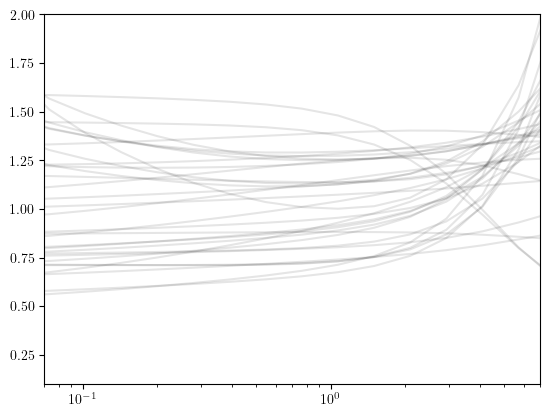

In [10]:
# rho_b_model_all_samp.shape

pl.figure()
for ji in range(rho_b_model_all_samp.shape[0]):
    pl.plot(r_array, rho_b_model_all_samp[ji, :, 12]/rho_baryon_mat_z0_fid[:,12], alpha=0.1, color='k')
    
pl.xscale('log')
# pl.yscale('log')
pl.xlim(0.07, 7)
# pl.ylim(1e9, 1e13)
pl.ylim(0.1, 2)





(0.1, 2.0)

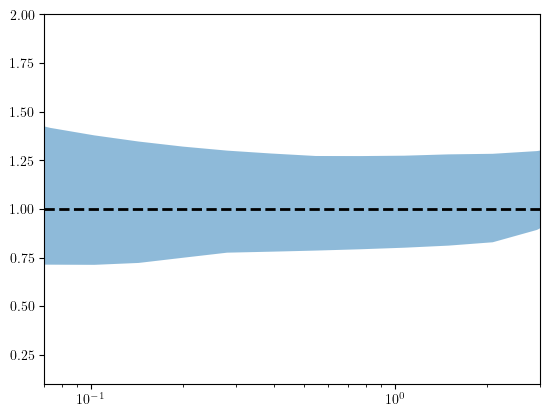

In [12]:
# rho_b_model_all_samp.shape

pl.figure()
# for ji in range(rho_b_model_all_samp.shape[0]):
    # pl.plot(r_array, rho_b_model_all_samp[ji, :, 12]/rho_baryon_mat_z0_fid[:,12], alpha=0.1, color='k')
pl.fill_between(r_array, rho_b_ratio_samps_min, rho_b_ratio_samps_max, alpha=0.5)
pl.axhline(1.0, ls='--', lw=2.0, color='k')
pl.xscale('log')
# pl.yscale('log')
pl.xlim(0.07, 3)
# pl.ylim(1e9, 1e13)
pl.ylim(0.1, 2)





(0.1, 2.0)

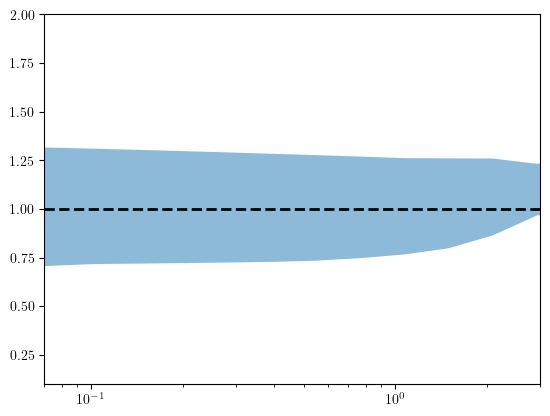

In [16]:
# rho_b_model_all_samp.shape

pl.figure()
# for ji in range(rho_b_model_all_samp.shape[0]):
    # pl.plot(r_array, rho_b_model_all_samp[ji, :, 12]/rho_baryon_mat_z0_fid[:,12], alpha=0.1, color='k')
pl.fill_between(r_array, rho_b_ratio_samps_min, rho_b_ratio_samps_max, alpha=0.5)
pl.axhline(1.0, ls='--', lw=2.0, color='k')
pl.xscale('log')
# pl.yscale('log')
# pl.xlim(0.07, 7)
pl.xlim(0.07, 3)
# pl.ylim(1e9, 1e13)
pl.ylim(0.1, 2)





(0.1, 2.0)

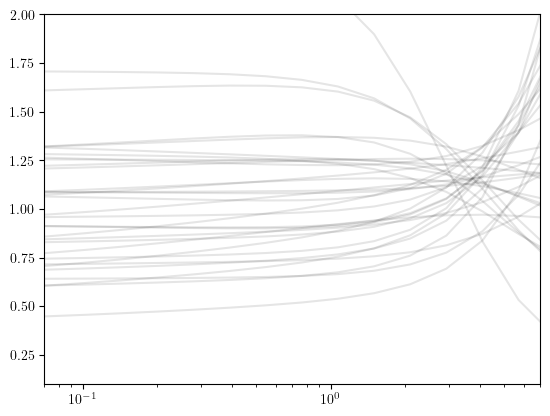

In [17]:
# rho_b_model_all_samp.shape

pl.figure()
for ji in range(rho_b_model_all_samp.shape[0]):
    pl.plot(r_array, rho_b_model_all_samp[ji, :, 12]/rho_baryon_mat_z0_fid[:,12], alpha=0.1, color='k')
    
pl.xscale('log')
# pl.yscale('log')
pl.xlim(0.07, 7)
# pl.ylim(1e9, 1e13)
pl.ylim(0.1, 2)




(0.1, 2.0)

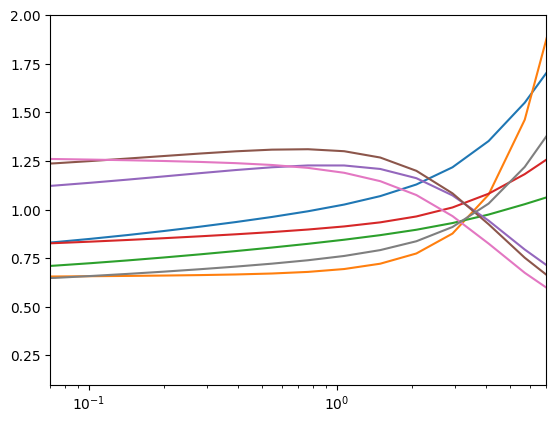

In [25]:
# rho_b_model_all_samp.shape
pl.figure()
for ji in range(rho_b_model_all_samp.shape[0]):
    pl.plot(r_array, rho_b_model_all_samp[ji, :, 12]/rho_baryon_mat_z0_fid[:,12])
pl.xscale('log')
# pl.yscale('log')
pl.xlim(0.07, 7)
# pl.ylim(1e9, 1e13)
pl.ylim(0.1, 2)



In [8]:
# # Pmm_ratio_all_samp
# for jind, map_ind in tqdm(enumerate(indsel)):
#     saved_bestfit = {}
#     for jk, key in enumerate(keys):
#         saved_bestfit[key] = samps[map_ind, jk]

#     sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = get_dicts_default()
    
#     for key in saved_bestfit.keys():
#         if key in list(sim_params_dict.keys()):
#             # sim_params_dict[key] = float(saved_bestfit[key])
#             print(key, saved_bestfit[key])


0it [00:00, ?it/s]/tmp/ipykernel_4026308/431644236.py:209: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_4026308/431644236.py:215: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_4026308/431644236.py:263: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_4026308/431644236.py:268: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integ

alpha_nt 0.46239340387380595
alphasat_Nsat 1.2126875054777626
delta_a_fshmr 0.18721509397871294
delta_fshmr 0.32129160876669066
gamma_a_fshmr 0.08901770292541103
gamma_fshmr 1.6825208920379844
log10M1_a_fshmr 0.5240579244334272
log10M1_fshmr 12.59458754304763
mu_beta 0.6065993899540492
nu_theta_ej_M -0.2557877217524389
nu_theta_ej_z -1.2862191152198519
siglogMstar_Ncen 0.7724515656279493
theta_ej_0 3.3024243913247093
alpha_nt 0.1336919758997177
alphasat_Nsat 1.1928749507898755
delta_a_fshmr 0.1475293892232532
delta_fshmr 0.3218737376135654
gamma_a_fshmr -1.94353061713106
gamma_fshmr 1.178147319853994
log10M1_a_fshmr 0.28633986866636985
log10M1_fshmr 12.332871968966892
mu_beta 0.31642799828722146
nu_theta_ej_M -0.3497303653413659
nu_theta_ej_z -1.7140064079145034
siglogMstar_Ncen 0.6959802592787154
theta_ej_0 2.3248811488887844


4it [00:00,  5.01it/s]

alpha_nt 0.4544354416111406
alphasat_Nsat 1.2197914761910975
delta_a_fshmr 0.1958157594692631
delta_fshmr 0.36961039226434106
gamma_a_fshmr -1.8698270830678647
gamma_fshmr 0.9556037188690509
log10M1_a_fshmr 0.3095093140542451
log10M1_fshmr 12.163107677745899
mu_beta 0.5451992291414435
nu_theta_ej_M -0.4010125051642174
nu_theta_ej_z -1.5332120374400504
siglogMstar_Ncen 0.6636755494379306
theta_ej_0 1.6909071238966473
alpha_nt 0.2803086712047007
alphasat_Nsat 1.205112296545621
delta_a_fshmr 0.24347142120332124
delta_fshmr 0.41035895693249325
gamma_a_fshmr -0.39872054149476926
gamma_fshmr 1.8531147971935957
log10M1_a_fshmr 0.4595650848313326
log10M1_fshmr 12.515067987318094
mu_beta 0.17464691350932404
nu_theta_ej_M -0.37305750087687617
nu_theta_ej_z -1.3828918630558356
siglogMstar_Ncen 0.6465725988466392
theta_ej_0 1.767556216400799


6it [00:01,  5.08it/s]

alpha_nt 0.35541130403475896
alphasat_Nsat 1.210750199192122
delta_a_fshmr 0.15878838214959323
delta_fshmr 0.3598151386296494
gamma_a_fshmr -0.7004601089464324
gamma_fshmr 1.3361930438474703
log10M1_a_fshmr 0.7679969792843142
log10M1_fshmr 12.084486482940303
mu_beta 0.17480194952228956
nu_theta_ej_M -0.37680174367412944
nu_theta_ej_z -1.4261655561612987
siglogMstar_Ncen 0.6309597689224935
theta_ej_0 2.1479120326080694
alpha_nt 0.3040927450535962
alphasat_Nsat 1.2052089407073963
delta_a_fshmr 0.17659782592543127
delta_fshmr 0.3383983482252231
gamma_a_fshmr -1.7907096908058089
gamma_fshmr 0.8475149042562724
log10M1_a_fshmr 0.11434446141242323
log10M1_fshmr 12.194500796791479
mu_beta 0.390091031052948
nu_theta_ej_M -0.35979966721730583
nu_theta_ej_z -1.2283760830233499
siglogMstar_Ncen 0.7059082191074164
theta_ej_0 1.748088292488624


8it [00:01,  5.06it/s]

alpha_nt 0.23260824113768563
alphasat_Nsat 1.179422237121324
delta_a_fshmr 0.19269269995548358
delta_fshmr 0.3410170014081001
gamma_a_fshmr -1.2457056503707975
gamma_fshmr 2.294215628005745
log10M1_a_fshmr 0.5268131885535663
log10M1_fshmr 12.747785667917068
mu_beta 0.3523558091539993
nu_theta_ej_M -0.30515177737273486
nu_theta_ej_z -1.6964729982040068
siglogMstar_Ncen 0.7196326292493853
theta_ej_0 2.7307500507123597
alpha_nt 0.27251401986929447
alphasat_Nsat 1.207843809003309
delta_a_fshmr 0.2209565530503698
delta_fshmr 0.36883543025399224
gamma_a_fshmr -1.6730036988640091
gamma_fshmr 1.3123007271139413
log10M1_a_fshmr 0.2826102122684988
log10M1_fshmr 12.45393222328348
mu_beta 0.4796820773406509
nu_theta_ej_M -0.2522398906041022
nu_theta_ej_z -1.3754173485017813
siglogMstar_Ncen 0.707814730871544
theta_ej_0 3.0932378075394973
